### This notebook is just answers the following questions:
- Can I access HEST?
- Did the files download?
- Can I load the metadata?
- Can I identify coordinates?
- Can I identify expression matrix?
- Can I connect one spot to one H&E patch?

The goal is just verifying that the data exists locally and that we can access different parts of it.

In [4]:
# Setup libraries
from pathlib import Path
import os
import json
import glob
import warnings

# Data manipulation libraries
import numpy as np
import pandas as pd

# Ignoring warnings for a cleaner output
warnings.filterwarnings("ignore")

# Function to find the project root directory
def find_project_root(start_path=None, repo_name="HistoGeneAlign"):
    if start_path is None:
        start_path = Path.cwd()

    start_path = Path(start_path).resolve()

    # Walk upward until we find the repo structure
    for path in [start_path] + list(start_path.parents):
        has_repo_folders = (
            (path / "data").exists()
            and (path / "notebooks").exists()
            and (path / "scripts").exists()
        )

        has_repo_name = path.name == repo_name

        if has_repo_folders or has_repo_name:
            return path

    # Fallback: if currently inside notebooks/, parent is probably repo root
    if start_path.name == "notebooks":
        return start_path.parent

    return start_path


# Defining the project directories
PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "hest"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PATCH_DIR = PROJECT_ROOT / "data" / "patches"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

# Creating directories if they don't exist
for path in [RAW_DIR, PROCESSED_DIR, PATCH_DIR, OUTPUT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Printing out the paths to verigy
print("Current working directory:", Path.cwd().resolve())
print("Detected project root:", PROJECT_ROOT)
print("Raw HEST directory:", RAW_DIR)
print("Raw directory exists:", RAW_DIR.exists())

Current working directory: C:\Users\Hareen\Desktop\HistoGeneAlign\notebooks
Detected project root: C:\Users\Hareen\Desktop\HistoGeneAlign
Raw HEST directory: C:\Users\Hareen\Desktop\HistoGeneAlign\data\raw\hest
Raw directory exists: True


### Helper function for reading tables

In [5]:
def read_table_safely(path: Path):
    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)
    elif suffix == ".tsv":
        return pd.read_csv(path, sep="\t")
    elif suffix == ".parquet":
        return pd.read_parquet(path)
    elif suffix == ".json":
        try:
            return pd.read_json(path)
        except Exception:
            with open(path, "r") as f:
                obj = json.load(f)
            return pd.json_normalize(obj)
    else:
        raise ValueError(f"Unsupported table format: {suffix}")

### Checking the HEST access

In [6]:
# Checking the access to the HEST dataset on Hugging Face
try:
    from huggingface_hub import HfApi

    api = HfApi()
    repo_info = api.dataset_info("MahmoodLab/hest")

    print("HEST access check: PASSED")
    print("Dataset repo:", repo_info.id)
    print("Private/gated:", getattr(repo_info, "gated", "unknown"))
    print("Last modified:", getattr(repo_info, "last_modified", "unknown"))
    print("Number of files listed:", len(repo_info.siblings))

# Fallback if the dataset is not accessible
except Exception as e:
    print("HEST access check: FAILED")
    print("Reason:", repr(e))
    print()
    print("Fix options:")
    print("1. Run: huggingface-cli login")
    print("2. Accept the HEST dataset access conditions on Hugging Face.")
    print("3. Confirm internet access from this Python environment.")

HEST access check: PASSED
Dataset repo: MahmoodLab/hest
Private/gated: auto
Last modified: 2026-02-08 12:55:58+00:00
Number of files listed: 15608


### Checking the downloaded files

In [7]:
all_files = [p for p in RAW_DIR.rglob("*") if p.is_file()]

print("Total files found:", len(all_files))

if len(all_files) == 0:
    print("No files found in data/raw/hest/.")
    print("Download one HEST subset first, then rerun this notebook.")
else:
    file_summary = (
        pd.DataFrame({
            "path": [str(p.relative_to(RAW_DIR)) for p in all_files],
            "suffix": [p.suffix.lower() if p.suffix else "[no suffix]" for p in all_files],
            "size_mb": [p.stat().st_size / (1024 ** 2) for p in all_files],
        })
        .sort_values("size_mb", ascending=False)
    )

    display(file_summary.head(25))

    type_summary = (
        file_summary.groupby("suffix", as_index=False)
        .agg(
            file_count=("path", "count"),
            total_size_mb=("size_mb", "sum")
        )
        .sort_values("total_size_mb", ascending=False)
    )

    display(type_summary)

Total files found: 18


,path,suffix,size_mb
7,wsis\TENX95.tif,.tif,6.261027e+03
1,patches\TENX95.h5,.h5,1.121186e+03
5,st\TENX95.h5ad,.h5ad,1.687560e+01
2,patches_vis\TENX95_patch_vis.jpg,.jpg,6.858864e-01
4,spatial_plots\TENX95_spatial_plots.png,.png,2.793312e-01
3,pixel_size_vis\TENX95_pixel_size_vis.png,.png,2.120762e-01
6,thumbnails\TENX95_downscaled_fullres.jpeg,.jpeg,1.454515e-01
0,metadata\TENX95.json,.json,2.066612e-03
9,.cache\huggingface\CACHEDIR.TAG,.tag,1.859665e-04
13,.cache\huggingface\download\pixel_size_vis\TEN...,.metadata,1.220703e-04


,suffix,file_count,total_size_mb
8,.tif,1,6.261027e+03
0,.h5,1,1.121186e+03
1,.h5ad,1,1.687560e+01
3,.jpg,1,6.858864e-01
6,.png,2,4.914074e-01
2,.jpeg,1,1.454515e-01
4,.json,1,2.066612e-03
5,.metadata,8,9.527206e-04
7,.tag,1,1.859665e-04
9,[no suffix],1,9.536743e-07


### Loading the metadata

In [8]:
table_files = []

for ext in ["*.csv", "*.tsv", "*.parquet", "*.json"]:
    table_files.extend(RAW_DIR.rglob(ext))

print("Potential metadata/table files:", len(table_files))

for i, p in enumerate(table_files[:40]):
    print(f"{i:02d} | {p.relative_to(RAW_DIR)} | {p.stat().st_size / (1024 ** 2):.2f} MB")

metadata_df = None
metadata_path = None

for p in table_files:
    try:
        df = read_table_safely(p)

        if isinstance(df, pd.DataFrame) and df.shape[0] > 0 and df.shape[1] > 1:
            metadata_df = df
            metadata_path = p
            break

    except Exception:
        continue

if metadata_df is None:
    print("No readable metadata table found.")
else:
    print("Loaded metadata/table file:", metadata_path.relative_to(RAW_DIR))
    print("Shape:", metadata_df.shape)
    display(metadata_df.head())
    print("Columns:")
    print(list(metadata_df.columns))

Potential metadata/table files: 1
00 | metadata\TENX95.json | 0.00 MB
Loaded metadata/table file: metadata\TENX95.json
Shape: (8, 53)


,pixel_size_um_embedded,run_name,run_start_time,region_name,preservation_method,num_cells,transcripts_per_cell,transcripts_per_100um,cassette_name,slide_id,...,data_publication_date,license,study_link,download_page_link1,nb_genes,treatment_comment,magnification,tissue,disease_comment,subseries
morphology_filepath,1,human_breast_ffpe_predesigned_and_addon,2022-11-10 00:30:50+00:00,Xenium_V1_FFPE_Human_Breast_IDC,FFPE,574852,105,93.789537,SIM1,2429,...,2023-01-22,Creative Commons Attribution,NaN,https://www.10xgenomics.com/datasets/ffpe-huma...,541,NaN,40x,Breast,NaN,Tissue sample 1
morphology_mip_filepath,1,human_breast_ffpe_predesigned_and_addon,2022-11-10 00:30:50+00:00,Xenium_V1_FFPE_Human_Breast_IDC,FFPE,574852,105,93.789537,SIM1,2429,...,2023-01-22,Creative Commons Attribution,NaN,https://www.10xgenomics.com/datasets/ffpe-huma...,541,NaN,40x,Breast,NaN,Tissue sample 1
morphology_focus_filepath,1,human_breast_ffpe_predesigned_and_addon,2022-11-10 00:30:50+00:00,Xenium_V1_FFPE_Human_Breast_IDC,FFPE,574852,105,93.789537,SIM1,2429,...,2023-01-22,Creative Commons Attribution,NaN,https://www.10xgenomics.com/datasets/ffpe-huma...,541,NaN,40x,Breast,NaN,Tissue sample 1
transcripts_zarr_filepath,1,human_breast_ffpe_predesigned_and_addon,2022-11-10 00:30:50+00:00,Xenium_V1_FFPE_Human_Breast_IDC,FFPE,574852,105,93.789537,SIM1,2429,...,2023-01-22,Creative Commons Attribution,NaN,https://www.10xgenomics.com/datasets/ffpe-huma...,541,NaN,40x,Breast,NaN,Tissue sample 1
cells_zarr_filepath,1,human_breast_ffpe_predesigned_and_addon,2022-11-10 00:30:50+00:00,Xenium_V1_FFPE_Human_Breast_IDC,FFPE,574852,105,93.789537,SIM1,2429,...,2023-01-22,Creative Commons Attribution,NaN,https://www.10xgenomics.com/datasets/ffpe-huma...,541,NaN,40x,Breast,NaN,Tissue sample 1


Columns:
['pixel_size_um_embedded', 'run_name', 'run_start_time', 'region_name', 'preservation_method', 'num_cells', 'transcripts_per_cell', 'transcripts_per_100um', 'cassette_name', 'slide_id', 'panel_design_id', 'panel_name', 'panel_organism', 'panel_tissue_type', 'panel_num_targets_predesigned', 'panel_num_targets_custom', 'pixel_size', 'instrument_sn', 'instrument_sw_version', 'analysis_sw_version', 'experiment_uuid', 'cassette_uuid', 'roi_uuid', 'z_step_size', 'well_uuid', 'images', 'xenium_explorer_files', 'pixel_size_um_estimated', 'spot_diameter', 'inter_spot_dist', 'spots_under_tissue', 'adata_nb_col', 'fullres_px_width', 'fullres_px_height', 'dataset_title', 'id', 'image_filename', 'organ', 'disease_state', 'oncotree_code', 'species', 'patient', 'st_technology', 'data_publication_date', 'license', 'study_link', 'download_page_link1', 'nb_genes', 'treatment_comment', 'magnification', 'tissue', 'disease_comment', 'subseries']


### Identifying, Loading and Normaliziing the coordinate files

In [9]:
import scanpy as sc
import pandas as pd
import numpy as np
from pathlib import Path

h5ad_path = RAW_DIR / "st" / "TENX95.h5ad"

print("Checking:", h5ad_path)
print("Exists:", h5ad_path.exists())

if not h5ad_path.exists():
    raise FileNotFoundError(
        "st/TENX95.h5ad is missing. Download this file first."
    )

adata = sc.read_h5ad(h5ad_path)

print("\nAnnData loaded successfully.")
print("Shape: spots x genes =", adata.shape)

print("\nobs columns:")
print(list(adata.obs.columns))

print("\nvar columns:")
print(list(adata.var.columns))

print("\nobsm keys:")
print(list(adata.obsm.keys()))

display(adata.obs.head())
display(adata.var.head())

# ------------------------------------------------------------
# Coordinate extraction
# ------------------------------------------------------------

coords_norm = None

if "spatial" in adata.obsm:
    spatial = adata.obsm["spatial"]

    coords_norm = pd.DataFrame({
        "spot_id": adata.obs_names.astype(str),
        "x": spatial[:, 0],
        "y": spatial[:, 1],
    })

    print("\nCoordinates found in adata.obsm['spatial'].")

else:
    possible_x_cols = [
        c for c in adata.obs.columns
        if any(k in str(c).lower() for k in ["x", "pxl_col", "imagecol", "array_col"])
    ]

    possible_y_cols = [
        c for c in adata.obs.columns
        if any(k in str(c).lower() for k in ["y", "pxl_row", "imagerow", "array_row"])
    ]

    print("\nPossible x columns:", possible_x_cols)
    print("Possible y columns:", possible_y_cols)

    if len(possible_x_cols) > 0 and len(possible_y_cols) > 0:
        x_col = possible_x_cols[0]
        y_col = possible_y_cols[0]

        coords_norm = pd.DataFrame({
            "spot_id": adata.obs_names.astype(str),
            "x": adata.obs[x_col].values,
            "y": adata.obs[y_col].values,
        })

        print(f"\nCoordinates found in adata.obs using {x_col}, {y_col}.")

if coords_norm is None:
    print("\nNo coordinates found in AnnData.")
else:
    coords_norm["x"] = pd.to_numeric(coords_norm["x"], errors="coerce")
    coords_norm["y"] = pd.to_numeric(coords_norm["y"], errors="coerce")
    coords_norm = coords_norm.dropna(subset=["x", "y"])

    print("\nNormalized coordinate table:")
    print("Shape:", coords_norm.shape)
    display(coords_norm.head())

Checking: C:\Users\Hareen\Desktop\HistoGeneAlign\data\raw\hest\st\TENX95.h5ad
Exists: True

AnnData loaded successfully.
Shape: spots x genes = (11845, 541)

obs columns:
['in_tissue', 'pxl_col_in_fullres', 'pxl_row_in_fullres', 'array_col', 'array_row', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito']

var columns:
['mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts']

obsm keys:
['spatial']


,in_tissue,pxl_col_in_fullres,pxl_row_in_fullres,array_col,array_row,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mito,log1p_total_counts_mito,pct_counts_mito
000x000,True,249.515782,263.81301,0,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0,0.0,NaN
000x001,True,720.104017,263.81301,1,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0,0.0,NaN
000x002,True,1190.692253,263.81301,2,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0,0.0,NaN
000x003,True,1661.280488,263.81301,3,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0,0.0,NaN
000x004,True,2131.868723,263.81301,4,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0,0.0,NaN


,mito,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
TCIM,False,7854,19.488983,3.019887,33.693542,230847,12.349515
RUNX1,False,8391,156.311102,5.058225,29.159983,1851505,14.431510
SEC11C,False,7729,32.957282,3.525103,34.748839,390379,12.874876
BLANK_0418,False,1433,0.137189,0.128559,87.902068,1625,7.393878
LUM,False,8452,212.443985,5.363374,28.644998,2516399,14.738340



Coordinates found in adata.obsm['spatial'].

Normalized coordinate table:
Shape: (11845, 3)


,spot_id,x,y
0,000x000,249.515782,263.81301
1,000x001,720.104017,263.81301
2,000x002,1190.692253,263.81301
3,000x003,1661.280488,263.81301
4,000x004,2131.868723,263.81301


### Identifying & Loading the expression matrix candidates

In [11]:
# ------------------------------------------------------------
# Robust expression matrix checker for HEST / TENX95
# ------------------------------------------------------------

sample_id = "TENX95"

print("RAW_DIR:", RAW_DIR)
print("RAW_DIR exists:", RAW_DIR.exists())

# ------------------------------------------------------------
# 1. Find all possible expression files
# ------------------------------------------------------------

expression_extensions = ["*.h5ad", "*.h5", "*.mtx", "*.csv", "*.tsv", "*.parquet"]

expression_candidates = []

for ext in expression_extensions:
    expression_candidates.extend(RAW_DIR.rglob(ext))

print("\nAll possible expression/table candidates found:", len(expression_candidates))

for i, p in enumerate(expression_candidates[:100]):
    size_mb = p.stat().st_size / (1024 ** 2)
    print(f"{i:03d} | {p.relative_to(RAW_DIR)} | {size_mb:.2f} MB")

# ------------------------------------------------------------
# 2. Prioritize the expected HEST ST file
# ------------------------------------------------------------

expected_h5ad = RAW_DIR / "st" / f"{sample_id}.h5ad"

print("\nExpected ST AnnData file:")
print(expected_h5ad)
print("Exists:", expected_h5ad.exists())

expression_obj = None
expression_path = None
expression_type = None

# ------------------------------------------------------------
# 3. Load expected h5ad first
# ------------------------------------------------------------

if expected_h5ad.exists():
    expression_obj = sc.read_h5ad(expected_h5ad)
    expression_path = expected_h5ad
    expression_type = "h5ad"

# ------------------------------------------------------------
# 4. Fallback: load any h5ad containing the sample ID
# ------------------------------------------------------------

if expression_obj is None:
    h5ad_files = [
        p for p in expression_candidates
        if p.suffix.lower() == ".h5ad" and sample_id.lower() in str(p).lower()
    ]
    
    print("\nSample-matching h5ad files:", len(h5ad_files))
    
    for p in h5ad_files:
        print(" -", p.relative_to(RAW_DIR))
    
    if len(h5ad_files) > 0:
        expression_obj = sc.read_h5ad(h5ad_files[0])
        expression_path = h5ad_files[0]
        expression_type = "h5ad"

# ------------------------------------------------------------
# 5. Fallback: try any h5ad file
# ------------------------------------------------------------

if expression_obj is None:
    h5ad_files = [
        p for p in expression_candidates
        if p.suffix.lower() == ".h5ad"
    ]
    
    print("\nAny h5ad files found:", len(h5ad_files))
    
    for p in h5ad_files:
        print(" -", p.relative_to(RAW_DIR))
    
    if len(h5ad_files) > 0:
        expression_obj = sc.read_h5ad(h5ad_files[0])
        expression_path = h5ad_files[0]
        expression_type = "h5ad"

# ------------------------------------------------------------
# 6. Final result
# ------------------------------------------------------------

print("\n" + "#" * 100)

if expression_obj is None:
    print("FINAL RESULT: No expression matrix loaded.")
    print("Most likely issue: st/TENX95.h5ad has not been downloaded yet.")
    print("Download required file: st/TENX95.h5ad")

else:
    adata = expression_obj
    
    print("FINAL RESULT: Expression matrix loaded.")
    print("Expression file:", expression_path.relative_to(RAW_DIR))
    print("Expression type:", expression_type)
    print("Shape: spots x genes =", adata.shape)
    
    print("\nFirst 5 spot IDs:")
    print(list(adata.obs_names[:5]))
    
    print("\nFirst 5 gene IDs/names:")
    print(list(adata.var_names[:5]))
    
    print("\nobs columns:")
    print(list(adata.obs.columns))
    
    print("\nvar columns:")
    print(list(adata.var.columns))
    
    print("\nobsm keys:")
    print(list(adata.obsm.keys()))
    
    display(adata.obs.head())
    display(adata.var.head())
    
    # Create reusable expression identifiers
    expression_spot_ids = pd.Index(adata.obs_names.astype(str))
    expression_gene_count = adata.n_vars
    
    print("\nExpression spot/profile count:", len(expression_spot_ids))
    print("Gene count:", expression_gene_count)
    
    # Coordinate check from same AnnData object
    if "spatial" in adata.obsm:
        coords_norm = pd.DataFrame({
            "spot_id": adata.obs_names.astype(str),
            "x": adata.obsm["spatial"][:, 0],
            "y": adata.obsm["spatial"][:, 1],
        })
        
        print("\nSpatial coordinates found in adata.obsm['spatial'].")
        print("Coordinate shape:", coords_norm.shape)
        display(coords_norm.head())
        
    else:
        print("\nNo adata.obsm['spatial'] found.")
        print("Coordinates may be stored in adata.obs columns instead.")

RAW_DIR: C:\Users\Hareen\Desktop\HistoGeneAlign\data\raw\hest
RAW_DIR exists: True

All possible expression/table candidates found: 2
000 | st\TENX95.h5ad | 16.88 MB
001 | patches\TENX95.h5 | 1121.19 MB

Expected ST AnnData file:
C:\Users\Hareen\Desktop\HistoGeneAlign\data\raw\hest\st\TENX95.h5ad
Exists: True

####################################################################################################
FINAL RESULT: Expression matrix loaded.
Expression file: st\TENX95.h5ad
Expression type: h5ad
Shape: spots x genes = (11845, 541)

First 5 spot IDs:
['000x000', '000x001', '000x002', '000x003', '000x004']

First 5 gene IDs/names:
['TCIM', 'RUNX1', 'SEC11C', 'BLANK_0418', 'LUM']

obs columns:
['in_tissue', 'pxl_col_in_fullres', 'pxl_row_in_fullres', 'array_col', 'array_row', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', '

,in_tissue,pxl_col_in_fullres,pxl_row_in_fullres,array_col,array_row,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mito,log1p_total_counts_mito,pct_counts_mito
000x000,True,249.515782,263.81301,0,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0,0.0,NaN
000x001,True,720.104017,263.81301,1,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0,0.0,NaN
000x002,True,1190.692253,263.81301,2,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0,0.0,NaN
000x003,True,1661.280488,263.81301,3,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0,0.0,NaN
000x004,True,2131.868723,263.81301,4,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0,0.0,NaN


,mito,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
TCIM,False,7854,19.488983,3.019887,33.693542,230847,12.349515
RUNX1,False,8391,156.311102,5.058225,29.159983,1851505,14.431510
SEC11C,False,7729,32.957282,3.525103,34.748839,390379,12.874876
BLANK_0418,False,1433,0.137189,0.128559,87.902068,1625,7.393878
LUM,False,8452,212.443985,5.363374,28.644998,2516399,14.738340



Expression spot/profile count: 11845
Gene count: 541

Spatial coordinates found in adata.obsm['spatial'].
Coordinate shape: (11845, 3)


,spot_id,x,y
0,000x000,249.515782,263.81301
1,000x001,720.104017,263.81301
2,000x002,1190.692253,263.81301
3,000x003,1661.280488,263.81301
4,000x004,2131.868723,263.81301


### Creating expression spot ID index

In [12]:
expression_spot_ids = None
expression_gene_count = None

if expression_obj is None:
    print("Expression object is unavailable.")

elif expression_type in ["h5ad", "10x_h5"]:
    adata = expression_obj

    expression_spot_ids = pd.Index(adata.obs_names.astype(str))
    expression_gene_count = adata.n_vars

    print("Expression spot/profile count:", len(expression_spot_ids))
    print("Gene count:", expression_gene_count)
    print("First five expression spot IDs:", list(expression_spot_ids[:5]))

else:
    expr_df = expression_obj.copy()

    non_numeric_cols = list(expr_df.select_dtypes(exclude=[np.number]).columns)

    if len(non_numeric_cols) > 0:
        expr_id_col = non_numeric_cols[0]
        expression_spot_ids = pd.Index(expr_df[expr_id_col].astype(str))
        expression_gene_count = expr_df.select_dtypes(include=[np.number]).shape[1]

        print("Expression ID column:", expr_id_col)

    else:
        expression_spot_ids = pd.Index(expr_df.index.astype(str))
        expression_gene_count = expr_df.shape[1]

        print("Using table index as expression IDs.")

    print("Expression spot/profile count:", len(expression_spot_ids))
    print("Approximate gene/numeric feature count:", expression_gene_count)
    print("First five expression spot IDs:", list(expression_spot_ids[:5]))

Expression spot/profile count: 11845
Gene count: 541
First five expression spot IDs: ['000x000', '000x001', '000x002', '000x003', '000x004']


### Identifying H&E image files

In [13]:
image_suffixes = [
    ".svs",
    ".tif",
    ".tiff",
    ".png",
    ".jpg",
    ".jpeg",
    ".ome.tif",
    ".ome.tiff"
]

image_files = []

for p in all_files:
    name = p.name.lower()

    if any(name.endswith(s) for s in image_suffixes):
        image_files.append(p)

image_files = sorted(image_files, key=lambda p: p.stat().st_size, reverse=True)

print("Image-like files found:", len(image_files))

for i, p in enumerate(image_files[:30]):
    print(f"{i:02d} | {p.relative_to(RAW_DIR)} | {p.stat().st_size / (1024 ** 2):.2f} MB")

Image-like files found: 5
00 | wsis\TENX95.tif | 6261.03 MB
01 | patches_vis\TENX95_patch_vis.jpg | 0.69 MB
02 | spatial_plots\TENX95_spatial_plots.png | 0.28 MB
03 | pixel_size_vis\TENX95_pixel_size_vis.png | 0.21 MB
04 | thumbnails\TENX95_downscaled_fullres.jpeg | 0.15 MB


### Verifying the linked image-expression-coordinate record

In [14]:
linked_check = {
    "has_coordinates": coords_norm is not None and len(coords_norm) > 0,
    "has_expression": expression_spot_ids is not None and len(expression_spot_ids) > 0,
    "has_image": len(image_files) > 0,
}

print(linked_check)

linked_record = None

if all(linked_check.values()):
    coord_ids = pd.Index(coords_norm["spot_id"].astype(str))
    overlap = coord_ids.intersection(expression_spot_ids)

    print("Coordinate spots:", len(coord_ids))
    print("Expression spots:", len(expression_spot_ids))
    print("Overlapping spot IDs:", len(overlap))

    if len(overlap) > 0:
        chosen_spot = str(overlap[0])
        row = coords_norm[coords_norm["spot_id"].astype(str) == chosen_spot].iloc[0]

        linked_record = {
            "spot_id": chosen_spot,
            "x": float(row["x"]),
            "y": float(row["y"]),
            "image_file": str(image_files[0].relative_to(RAW_DIR)),
            "expression_available": True,
            "coordinate_available": True,
            "image_available": True,
        }

        print("Valid linked image-expression-coordinate spot found:")
        display(pd.DataFrame([linked_record]))

    else:
        print("Coordinates and expression loaded, but spot IDs do not overlap.")
        print("This may require barcode cleaning, sample filtering, or HEST-specific loading.")

else:
    print("Cannot create linked record yet.")
    print("Status:", linked_check)

{'has_coordinates': True, 'has_expression': True, 'has_image': True}
Coordinate spots: 11845
Expression spots: 11845
Overlapping spot IDs: 11845
Valid linked image-expression-coordinate spot found:


,spot_id,x,y,image_file,expression_available,coordinate_available,image_available
0,000x000,249.515782,263.81301,wsis\TENX95.tif,True,True,True


### Image Preview

Selected preview image: patches_vis\TENX95_patch_vis.jpg
Size MB: 0.686
Image size: (1700, 1880)


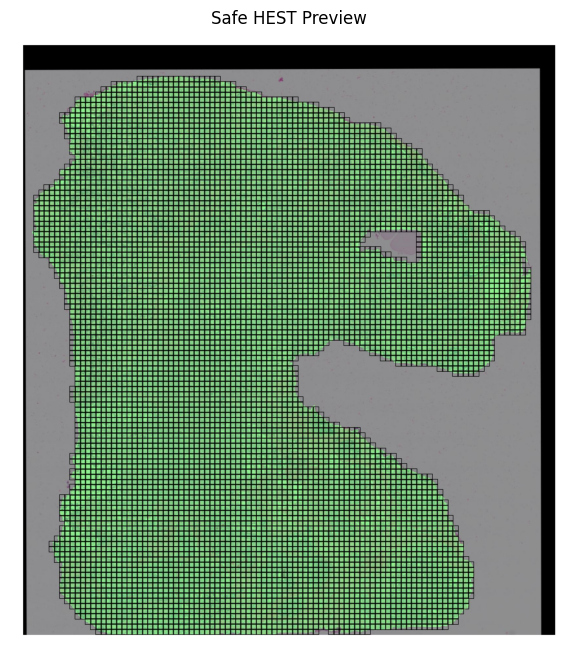

In [18]:
from PIL import Image
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Safe image preview for HEST
# Prefer small preview images over full WSI files
# ------------------------------------------------------------

preview_priority_keywords = [
    "thumbnail",
    "downscaled",
    "patch_vis",
    "spatial_plots",
    "pixel_size_vis"
]

preview_candidates = []

for p in image_files:
    rel = str(p.relative_to(RAW_DIR)).lower()
    
    if any(k in rel for k in preview_priority_keywords):
        preview_candidates.append(p)

# Fallback: use any image smaller than 50 MB
if len(preview_candidates) == 0:
    preview_candidates = [
        p for p in image_files
        if p.stat().st_size / (1024 ** 2) < 50
    ]

if len(preview_candidates) == 0:
    print("No safe preview image found.")
    print("Full WSI exists, but should not be opened directly with PIL.")
else:
    preview_path = preview_candidates[0]
    
    print("Selected preview image:", preview_path.relative_to(RAW_DIR))
    print("Size MB:", round(preview_path.stat().st_size / (1024 ** 2), 3))
    
    img = Image.open(preview_path)
    
    print("Image size:", img.size)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Safe HEST Preview")
    plt.show()

### Final Checklist

In [16]:
checklist = {
    "1_can_access_hest": "repo_info" in globals(),
    "2_files_downloaded": len(all_files) > 0,
    "3_metadata_loaded": metadata_df is not None,
    "4_coordinates_identified": coords_norm is not None and len(coords_norm) > 0,
    "5_expression_identified": expression_spot_ids is not None and len(expression_spot_ids) > 0,
    "6_one_spot_image_expression_linked": linked_record is not None,
}

checklist_df = pd.DataFrame(
    [{"question": k, "passed": v} for k, v in checklist.items()]
)

display(checklist_df)

if all(checklist.values()):
    print("Data download check PASSED.")
    print("Next step: create 02_data_exploration.ipynb.")
else:
    print("Data download check is incomplete.")
    print("Fix the failed rows before moving to patch extraction or model training.")

,question,passed
0,1_can_access_hest,True
1,2_files_downloaded,True
2,3_metadata_loaded,True
3,4_coordinates_identified,True
4,5_expression_identified,True
5,6_one_spot_image_expression_linked,True


Data download check PASSED.
Next step: create 02_data_exploration.ipynb.


### Saving the Linked record

In [17]:
if linked_record is not None:
    linked_record_path = PROCESSED_DIR / "first_linked_record.json"

    with open(linked_record_path, "w") as f:
        json.dump(linked_record, f, indent=4)

    print("Saved linked record to:", linked_record_path)

else:
    print("No linked record to save yet.")

Saved linked record to: C:\Users\Hareen\Desktop\HistoGeneAlign\data\processed\first_linked_record.json
